In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

%matplotlib inline

In [2]:
def pos_to_char(pos):
    return chr(pos + 65).lower()

In [3]:
sns.set_palette("tab10")

# Fixation times
### (1) Viability selection (constant population size), (2) Fecundity selection (constant population size)


In [4]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "adapted" not in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [5]:
sns.set(font_scale = 1.3, style="whitegrid")

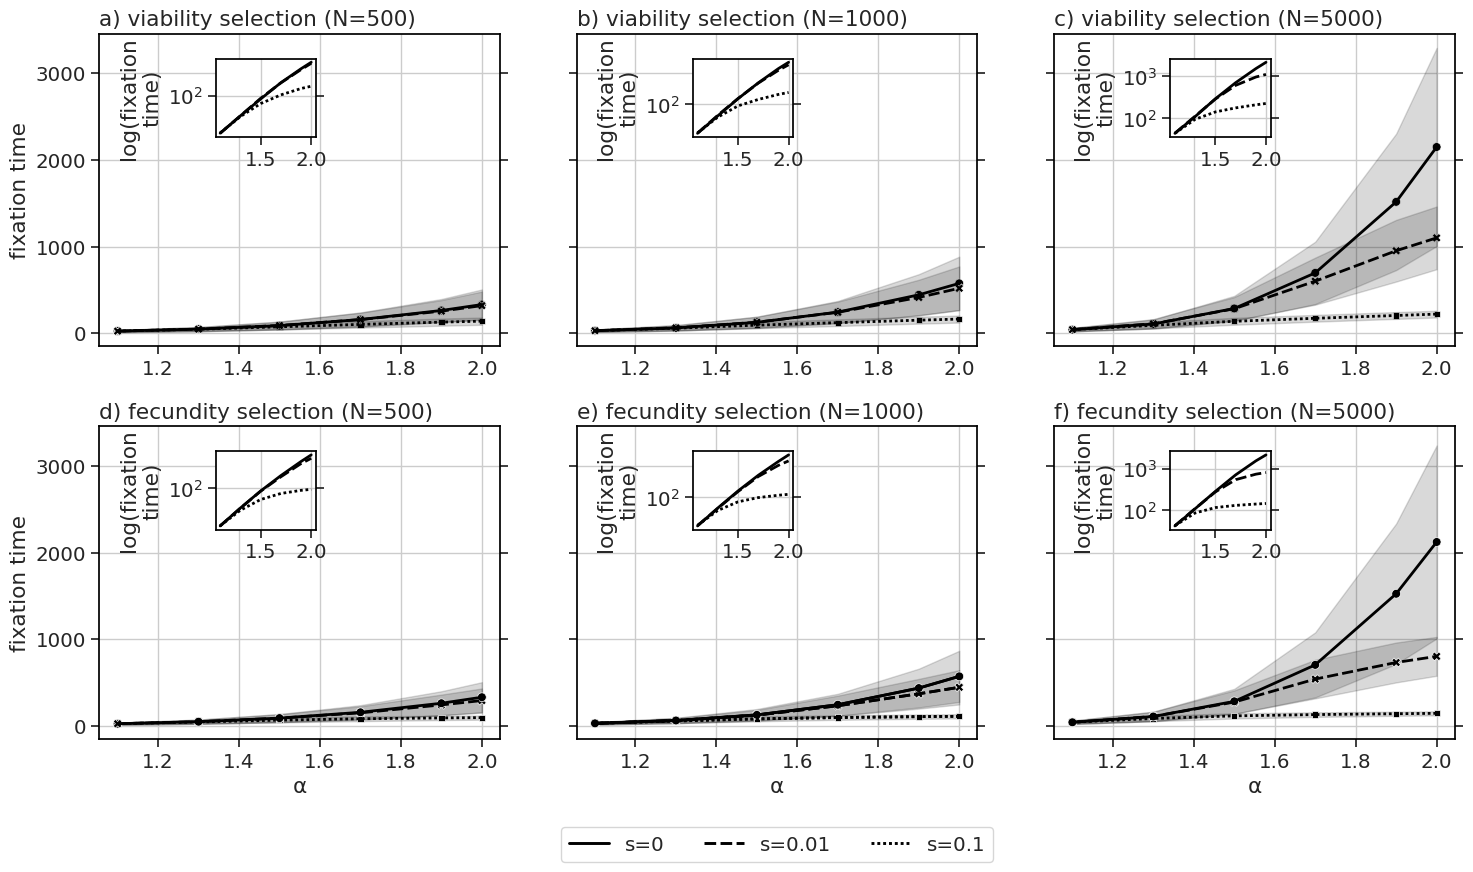

In [6]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate([500, 1000, 5000]):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_constant_selection_constant.pdf", dpi=500)

## (3) Difference between viability and fecundity selection (constant population size)

In [7]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the timess
df_time = [pd.read_csv(file) for file in files if "time" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "constant"]

In [8]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]

selection_coefficients = [0, 0.01, 0.1]
population_sizes = [500, 1000, 5000]

difference_frame = []

for population_size in population_sizes:

    for selection_coefficient in selection_coefficients:

        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation.item(), vc.standard_deviation.item()])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except:
                print(population_size, selection_coefficient, alpha, diff_std)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

500 0 1.3 12.276116536457842
500 0 1.5 12.276116536457842
500 0 1.7 12.276116536457842
500 0 1.9 12.276116536457842
500 0 2.0 12.276116536457842
500 0.01 1.3 12.478511312363427
500 0.01 1.5 12.478511312363427
500 0.01 1.7 12.478511312363427
500 0.01 1.9 12.478511312363427
500 0.01 2.0 12.478511312363427
500 0.1 1.3 11.781230649120566
500 0.1 1.5 11.781230649120566
500 0.1 1.7 11.781230649120566
500 0.1 1.9 11.781230649120566
500 0.1 2.0 11.781230649120566
1000 0 1.3 14.256639884709827
1000 0 1.5 14.256639884709827
1000 0 1.7 14.256639884709827
1000 0 1.9 14.256639884709827
1000 0 2.0 14.256639884709827
1000 0.01 1.3 14.44833130150565
1000 0.01 1.5 14.44833130150565
1000 0.01 1.7 14.44833130150565
1000 0.01 1.9 14.44833130150565
1000 0.01 2.0 14.44833130150565
1000 0.1 1.3 13.726861354834384
1000 0.1 1.5 13.726861354834384
1000 0.1 1.7 13.726861354834384
1000 0.1 1.9 13.726861354834384
1000 0.1 2.0 13.726861354834384
5000 0 1.3 19.83243313706323
5000 0 1.5 19.83243313706323
5000 0 1.7 1

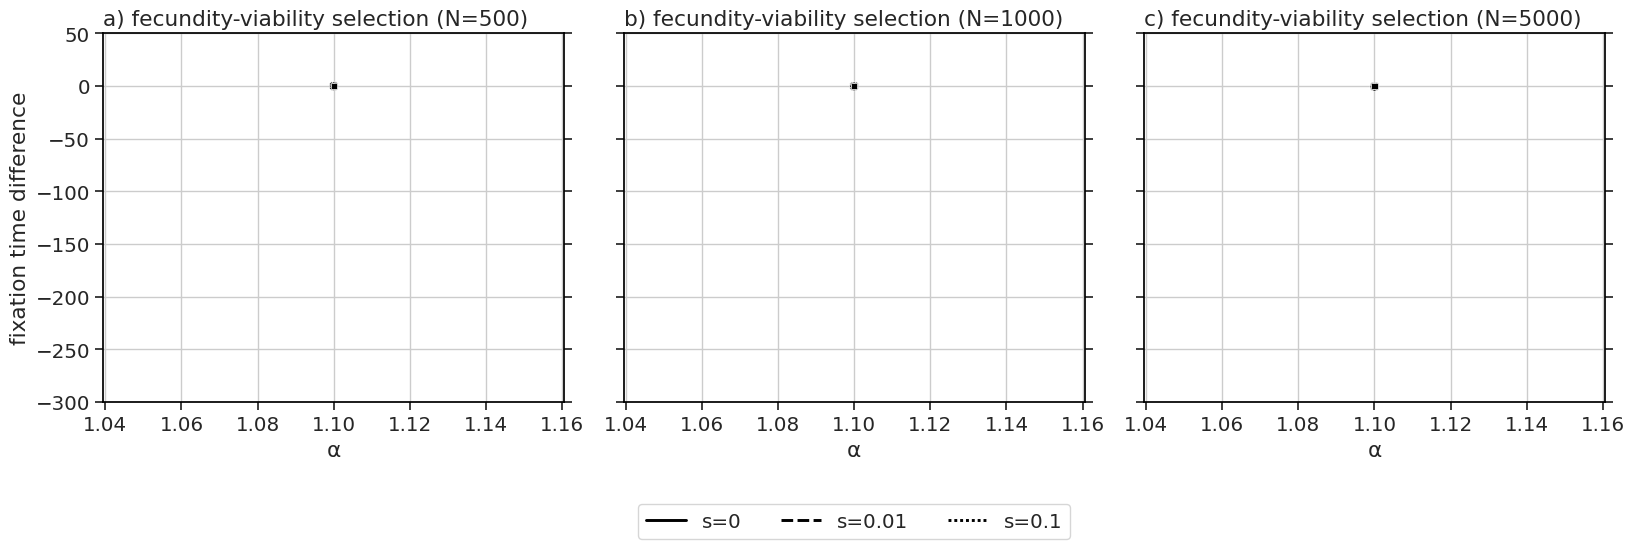

In [9]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.set_ylim(-300, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_constant_selection_constant.pdf", dpi=500)


## (4) Viability selection (sinus population size), (5) Fecundity selection (sinus population size)

In [10]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [11]:
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [12]:
sinus_population_size = sorted(df.population_size.unique().tolist()); sinus_population_size

[578, 1156, 5777]

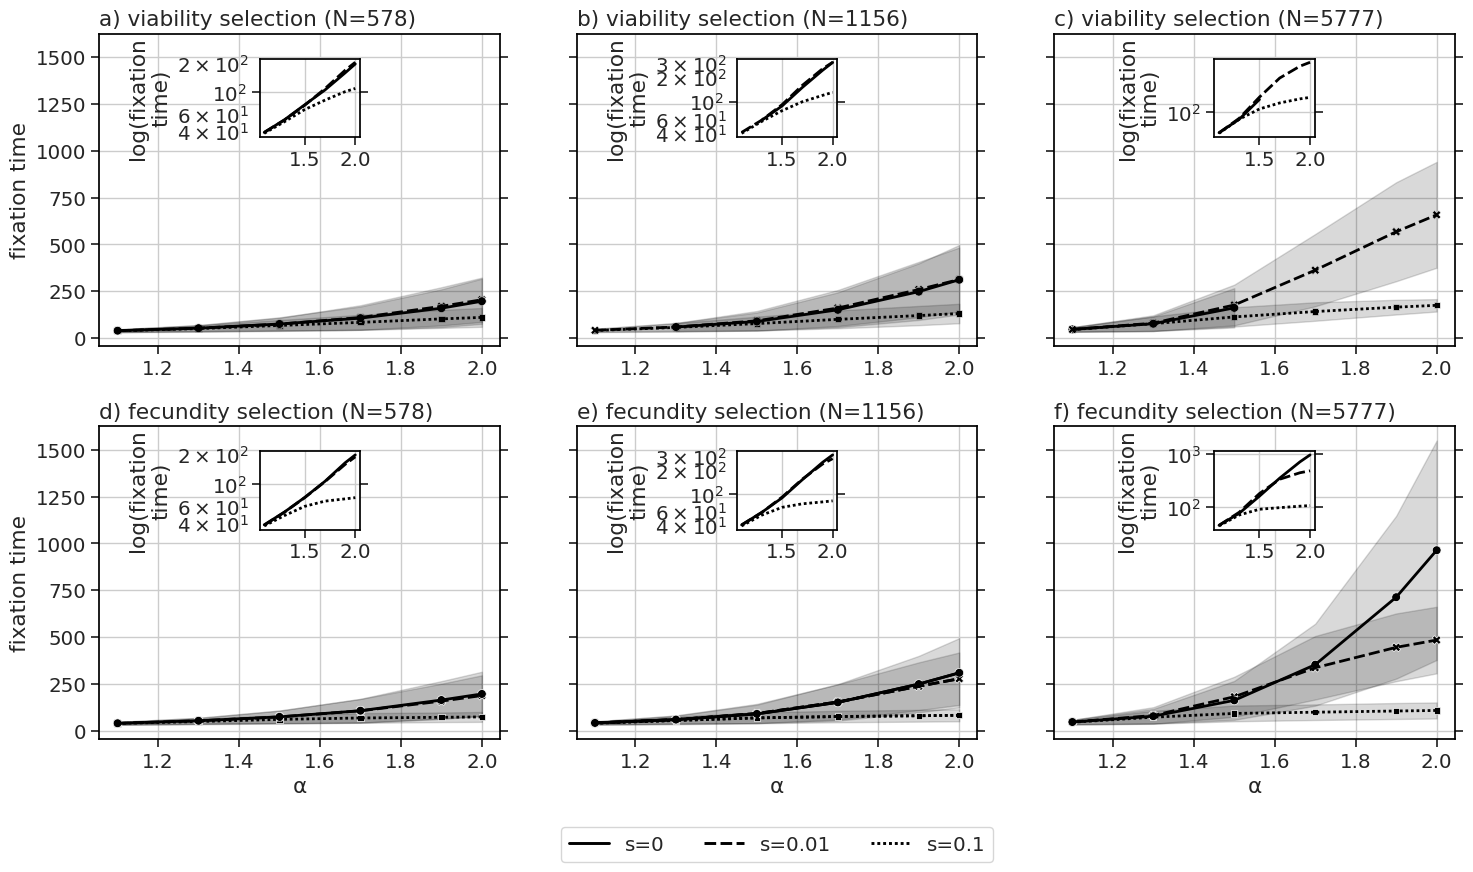

In [13]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.40, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.40, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_sinus_selection_constant.pdf", dpi=500)

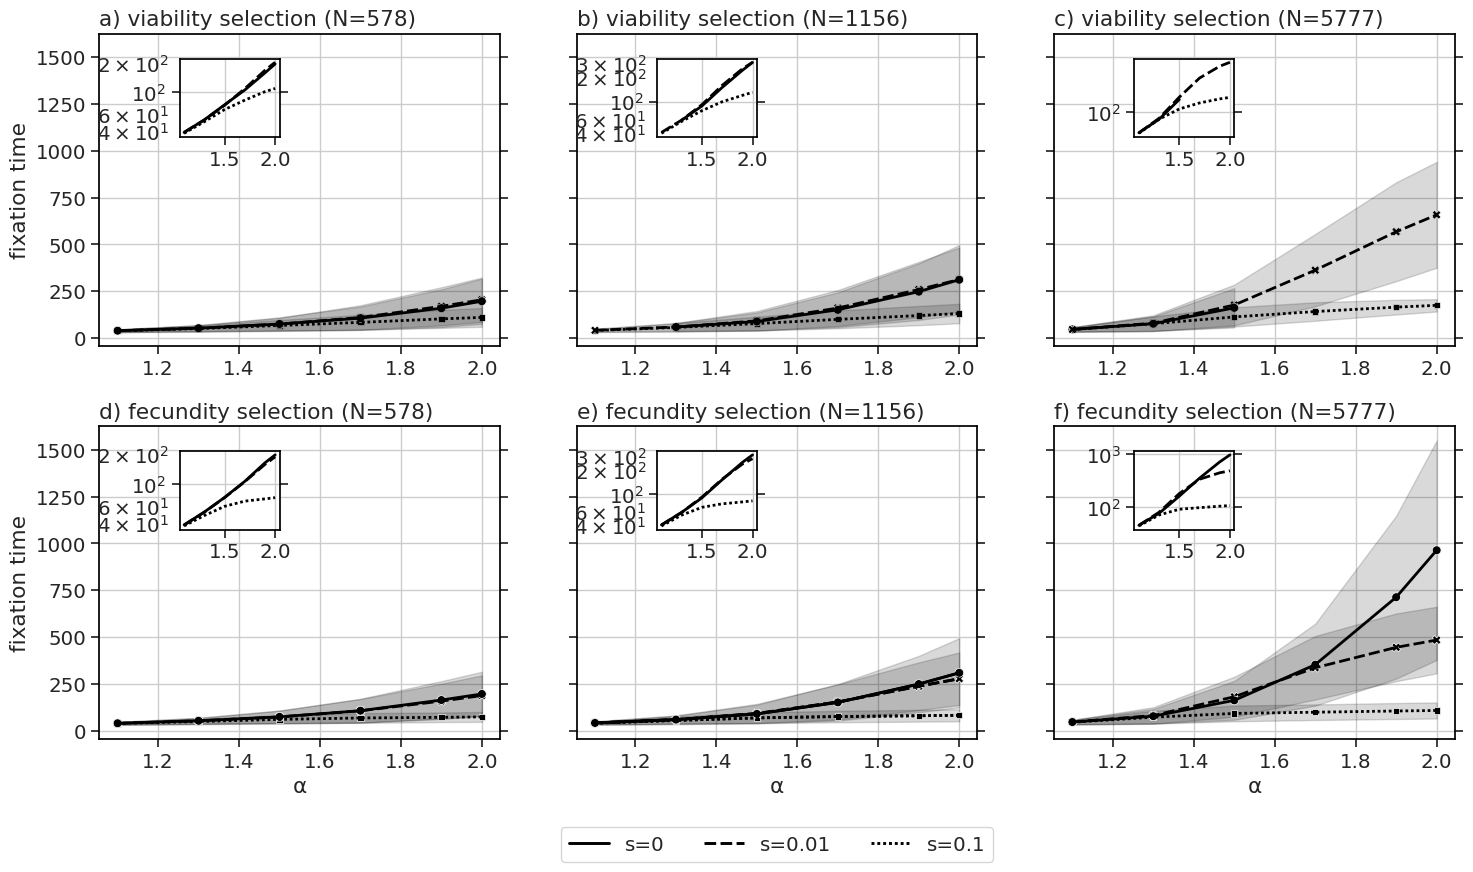

In [14]:
# new

sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.20, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.20, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_sinus_selection_constant.pdf", dpi=500)

## (6) Viability selection (shifted sinus population size), (7) Fecundity selection (shifted sinus population size)

In [15]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [16]:
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

In [17]:
sinus_population_size = sorted(df.population_size.unique().tolist()); sinus_population_size

[578, 1156, 5777]

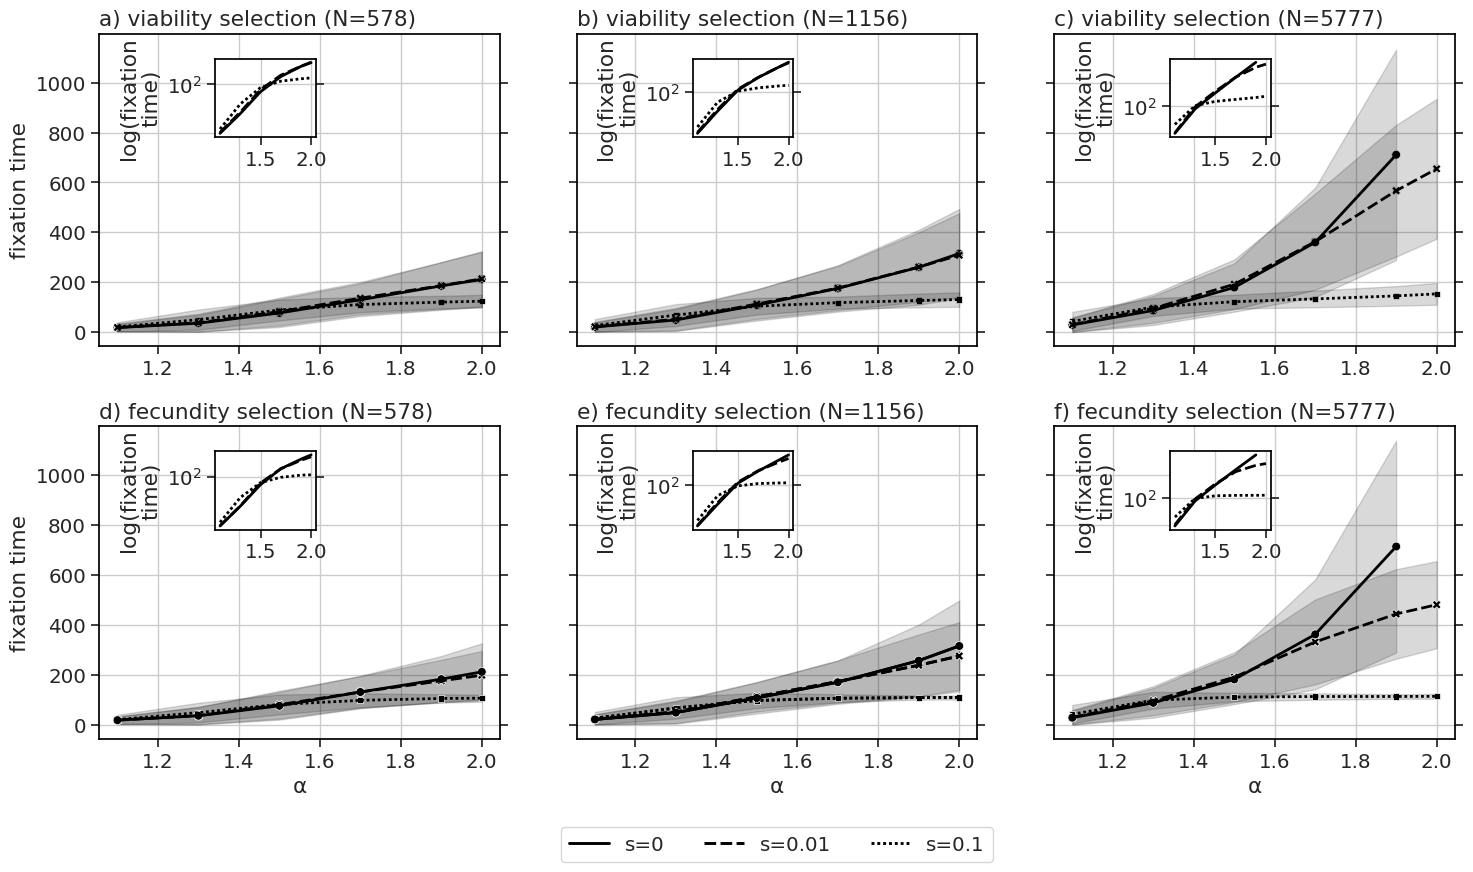

In [18]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)

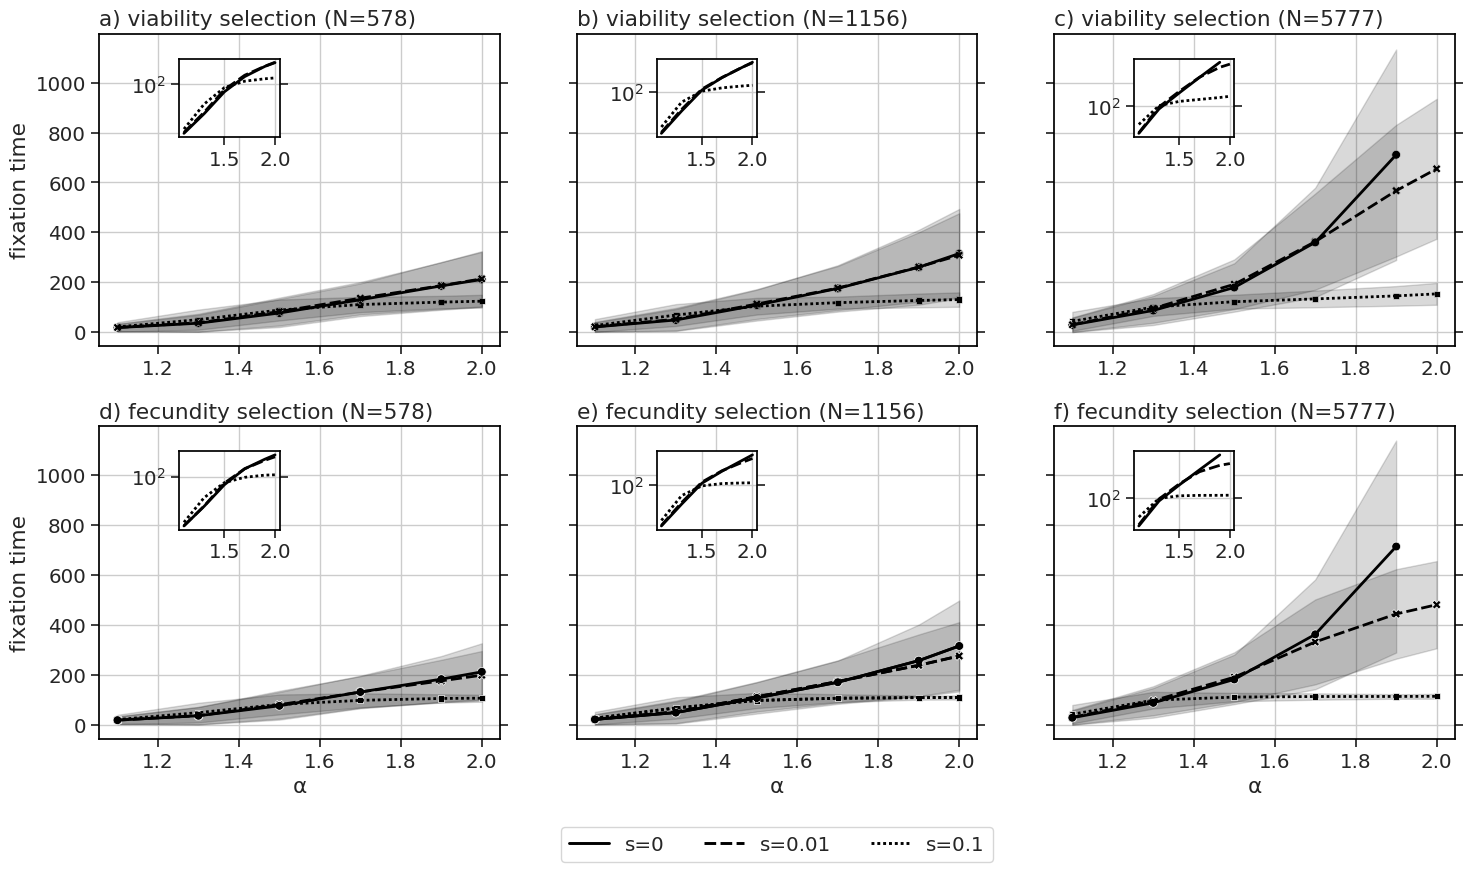

In [20]:
# new

sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate(sinus_population_size):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.2, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.2, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)

## (8) Difference between viability and fecundity selection (sinus population size)

In [ ]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [ ]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]

selection_coefficients = [0, 0.01, 0.1]

difference_frame = []
for population_size in sinus_population_size:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation, vc.standard_deviation])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except:
                print(population_size, selection_coefficient, alpha)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

1156 0 1.1
5777 0 1.7
5777 0 1.9
5777 0 2.0


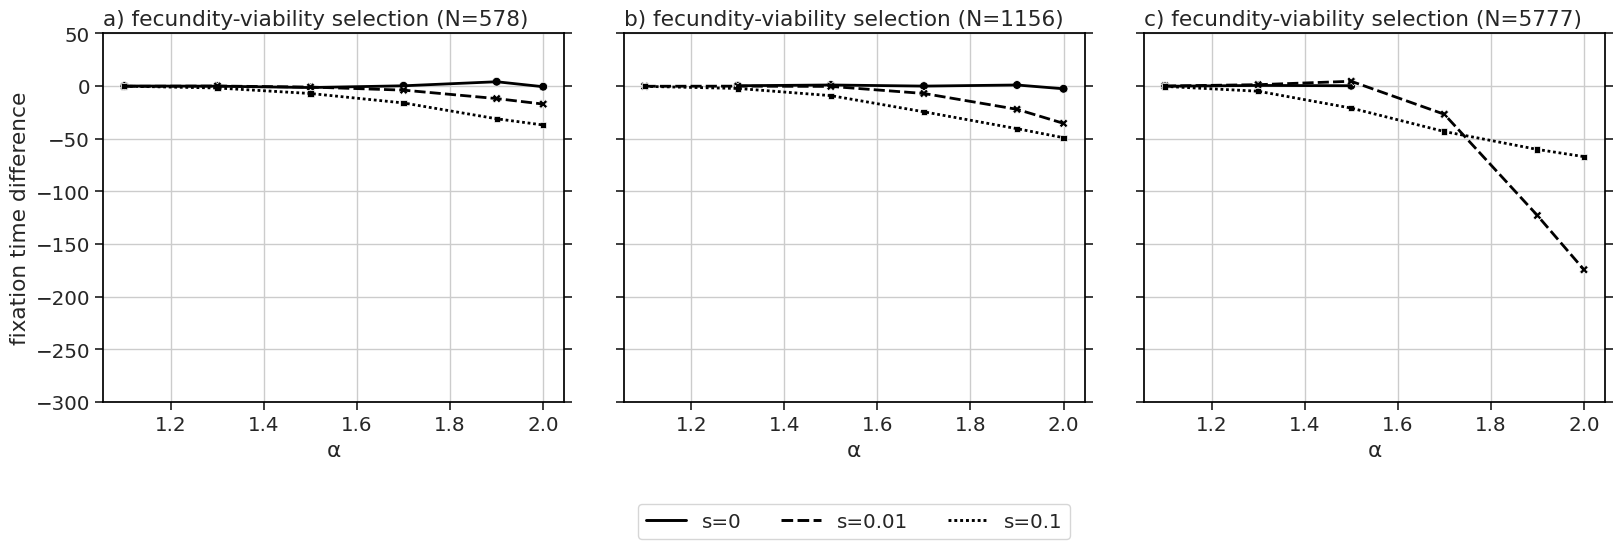

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.set_ylim(-300, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_sinus_selection_constant.pdf", dpi=500)


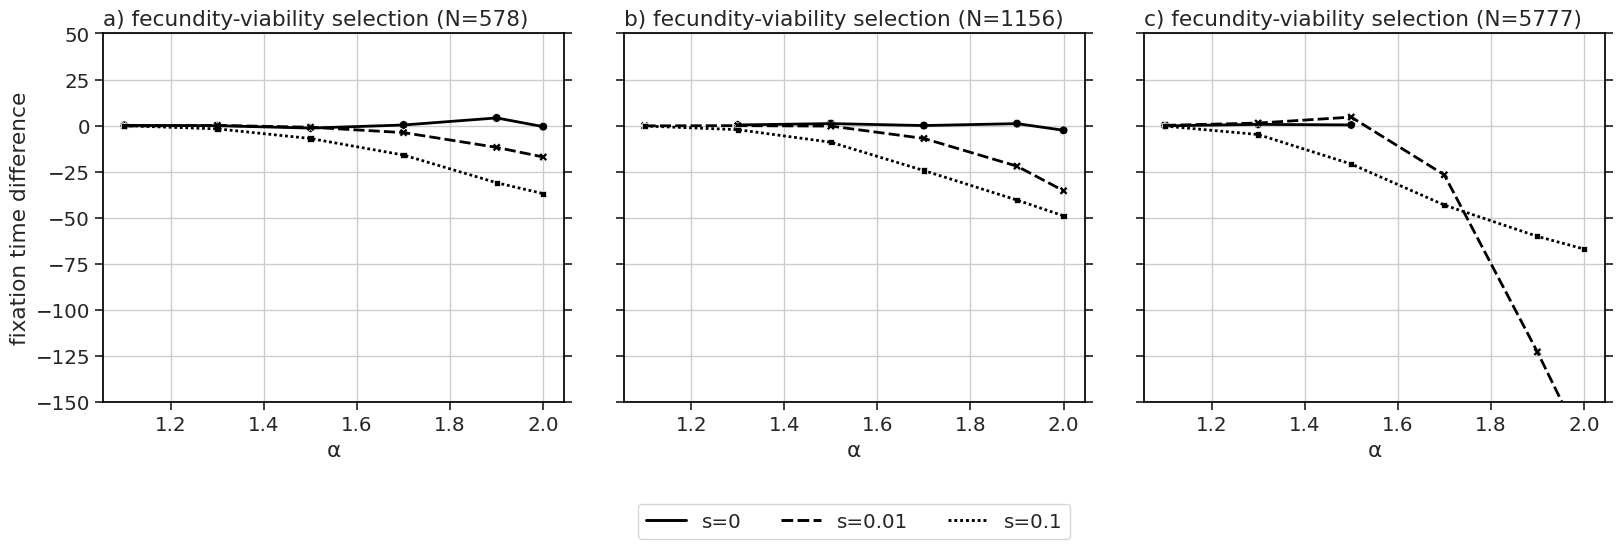

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth(2) 
    ax.set_ylim(-150, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_sinus_selection_constant.pdf", dpi=500)


## (9) Difference between viability and fecundity selection (sinus shifted population size)

In [ ]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()
df = df_time[df_time["population_size_model"] == "sinus"]

In [ ]:
fecundity_constant = df[df["selection_type"] == "fecundity_constant"]
viability_constant = df[df["selection_type"] == "viability_constant"]
selection_coefficients = [0, 0.01, 0.1]

difference_frame = []
for population_size in sinus_population_size:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_constant"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_constant"]
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation, vc.standard_deviation])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except:
                print(population_size, selection_coefficient, alpha)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

5777 0 1.3
5777 0 1.5
5777 0 1.7
5777 0 1.9
5777 0 2.0
5777 0.01 1.1
5777 0.01 1.3
5777 0.01 1.5
5777 0.01 1.7


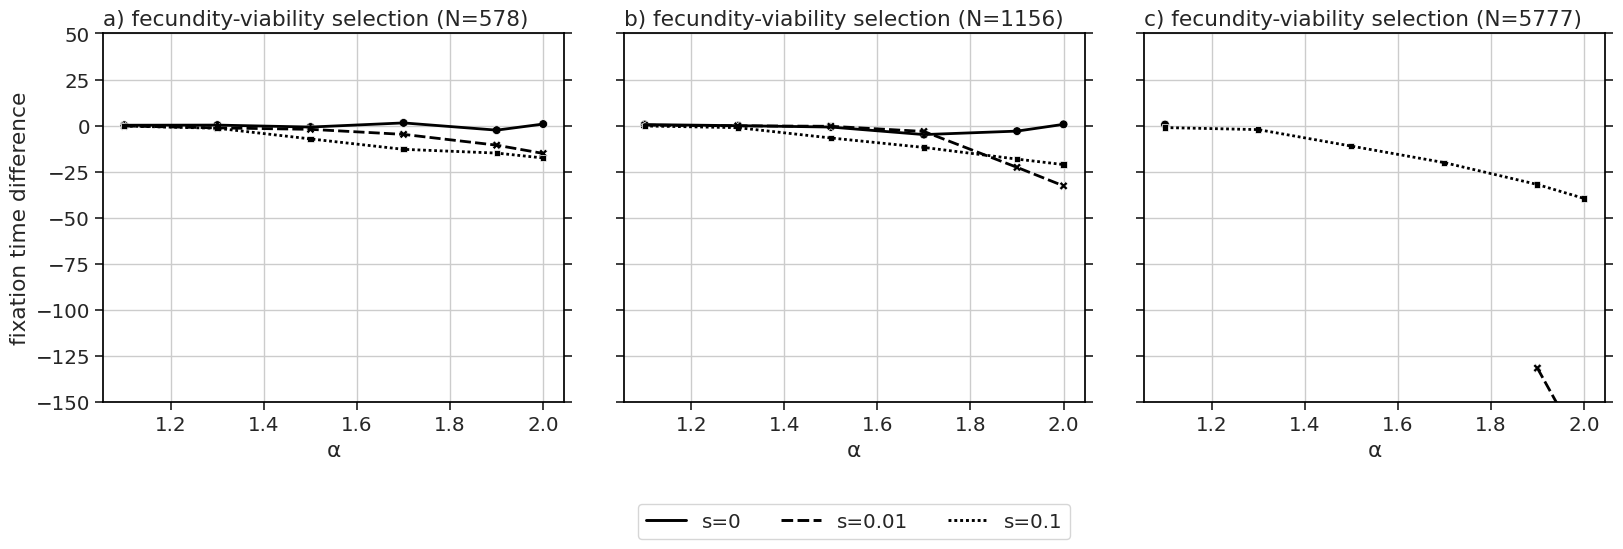

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(sinus_population_size):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth(2) 
    ax.set_ylim(-150, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_shifted_sinus_selection_constant.pdf", dpi=500)


## (10) Viability selection (sinus selection), (11) Fecundity selection (sinus selection)

In [ ]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

In [ ]:
viability_constant_df = df[df["selection_type"] == "viability_sinus"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_sinus"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

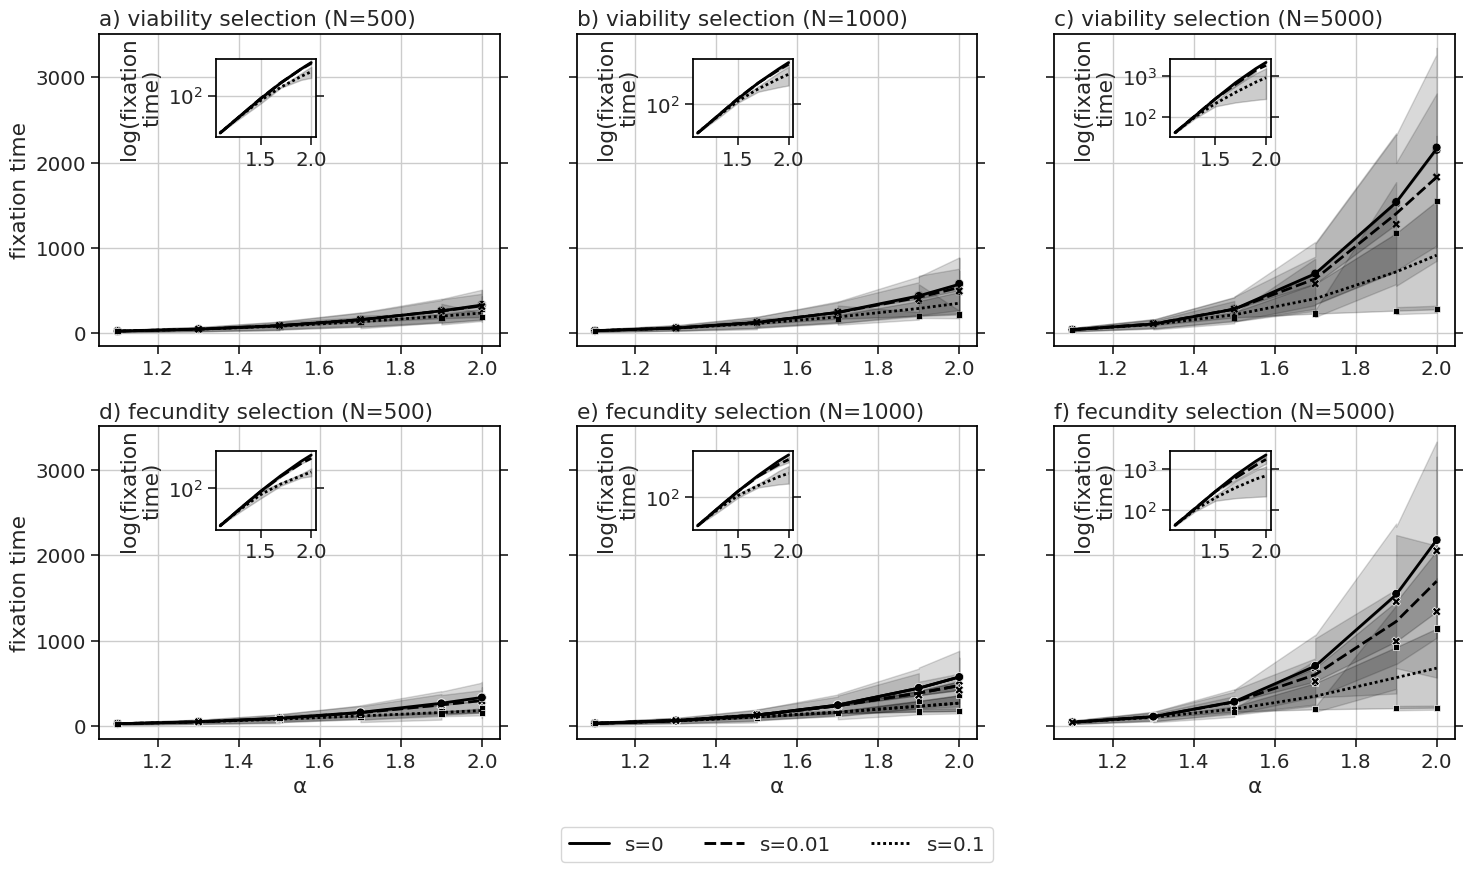

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate([500, 1000, 5000]):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_constant_selection_sinus.pdf", dpi=500)

## (12) Viability selection (shifted sinus selection), (13) Fecundity selection (shifted sinus selection)

In [ ]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

In [ ]:
viability_constant_df = df[df["selection_type"] == "viability_sinus"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_sinus"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

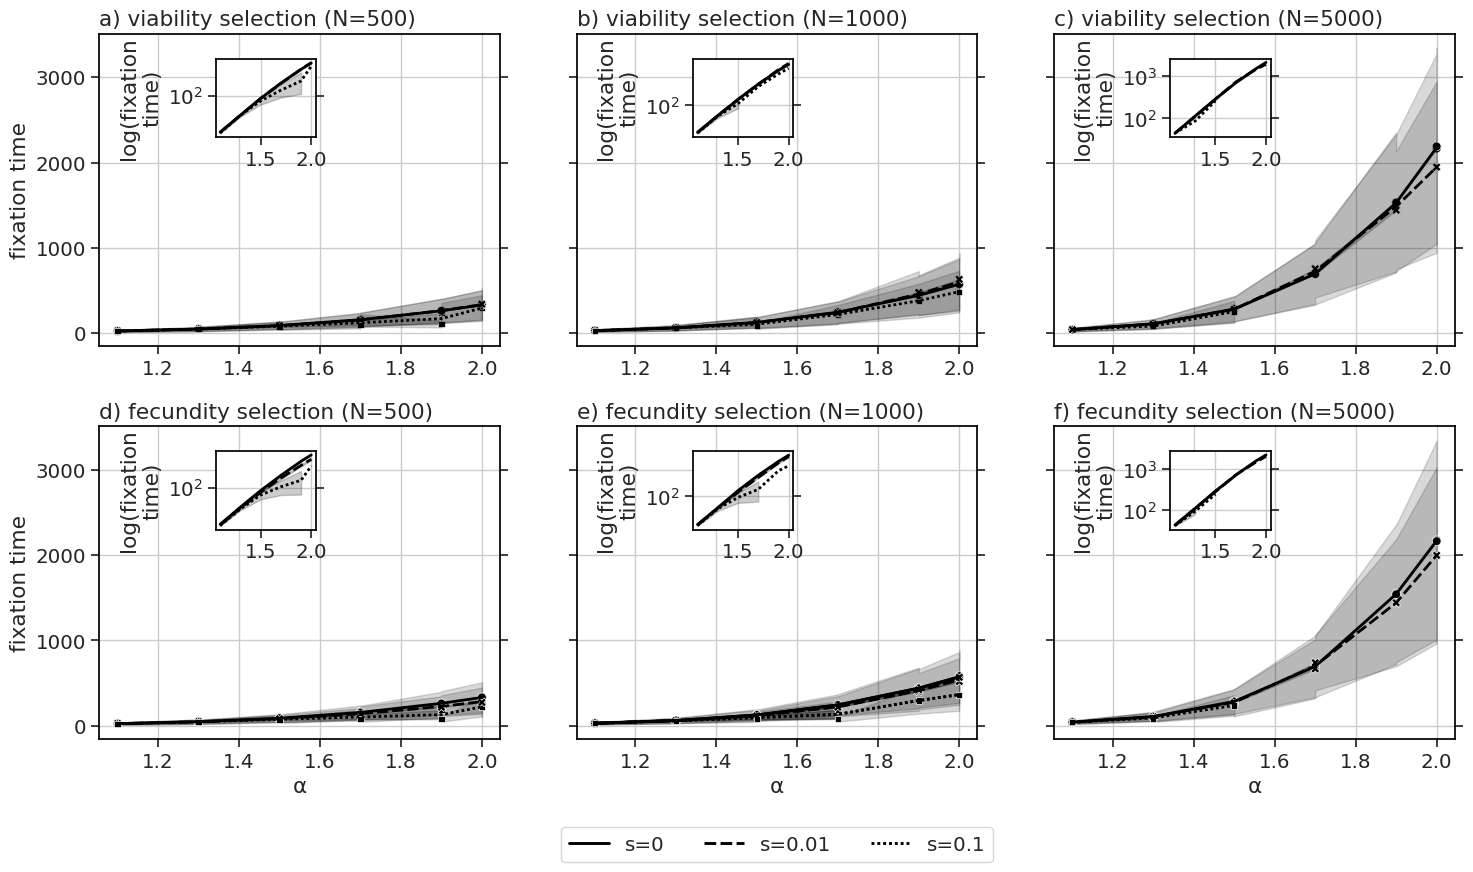

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2

for i, population_size in enumerate([500, 1000, 5000]):
    ax = axs[0][i]
    viability_constant_population_size = df = viability_constant_df[viability_constant_df["population_size"] == population_size]
    sns.lineplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    sns.scatterplot(data=viability_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") viability selection (N=" + str(population_size) + ")",  loc="left")
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = viability_constant_population_size[viability_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)


    
    ins = axs[0][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=viability_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='', ylabel='fixation time')
    
    
    ax = axs[1][i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i+3) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[1][i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25    
ncol=3
ax=axs[1][1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_constant_selection_shifted_sinus.pdf", dpi=500)

## (14) Difference between viability and fecundity selection (sinus selection)

In [ ]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_0.0" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
fecundity_constant = df[df["selection_type"] == "fecundity_sinus"]#.reset_index()
viability_constant = df[df["selection_type"] == "viability_sinus"]#.reset_index()

In [ ]:
difference_frame = []
for population_size in [500, 1000, 5000]:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_sinus"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_sinus"]
                #print(alpha, diff, population_size, selection_coefficient, [fc.standard_deviation, vc.standard_deviation])
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation, vc.standard_deviation])
                
                #print(diff, diff_std)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except Exception as e:
                print(population_size, selection_coefficient, alpha, e)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

500 0.01 1.1 can only convert an array of size 1 to a Python scalar
500 0.01 1.3 can only convert an array of size 1 to a Python scalar
500 0.01 1.5 can only convert an array of size 1 to a Python scalar
500 0.01 1.7 can only convert an array of size 1 to a Python scalar
500 0.01 1.9 can only convert an array of size 1 to a Python scalar
500 0.01 2.0 can only convert an array of size 1 to a Python scalar
500 0.1 1.1 can only convert an array of size 1 to a Python scalar
500 0.1 1.3 can only convert an array of size 1 to a Python scalar
500 0.1 1.5 can only convert an array of size 1 to a Python scalar
500 0.1 1.7 can only convert an array of size 1 to a Python scalar
500 0.1 1.9 can only convert an array of size 1 to a Python scalar
500 0.1 2.0 can only convert an array of size 1 to a Python scalar
500 0.0 1.1 can only convert an array of size 1 to a Python scalar
500 0.0 1.3 can only convert an array of size 1 to a Python scalar
500 0.0 1.5 can only convert an array of size 1 to a Pyt

/tmp/ipykernel_2921713/4013456455.py:41: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 3
  leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
/tmp/ipykernel_2921713/4013456455.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])


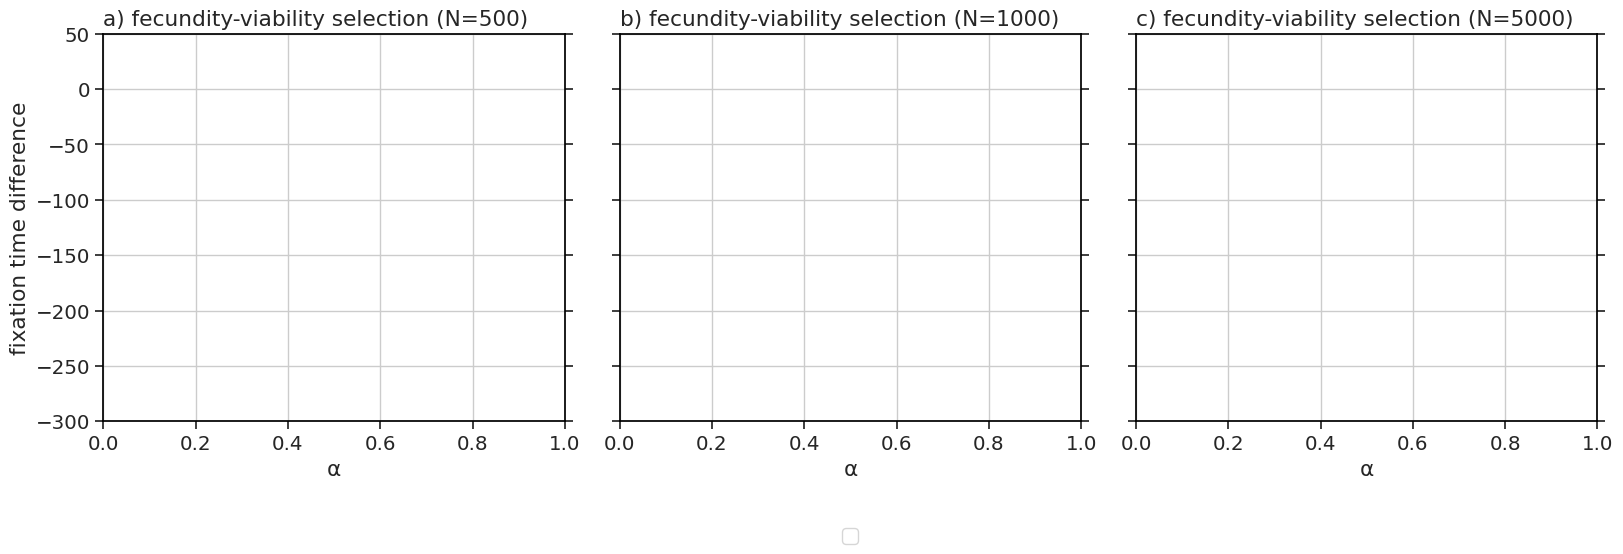

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.set_ylim(-300, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_constant_selection_sinus.pdf", dpi=500)


## (15) Difference between viability and fecundity selection (shifted sinus selection)

In [ ]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "shifted_3.1" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
fecundity_constant = df[df["selection_type"] == "fecundity_sinus"]#.reset_index()
viability_constant = df[df["selection_type"] == "viability_sinus"]#.reset_index()

In [ ]:


difference_frame = []
for population_size in [500, 1000, 5000]:

    for selection_coefficient in selection_coefficients:
        
        constant = pd.concat([fecundity_constant, viability_constant]).reset_index()
        constant = constant[constant["population_size"] == population_size]
        constant = constant[constant["selection_coefficient"] == selection_coefficient]

        for alpha in [1.1, 1.3, 1.5, 1.7, 1.9, 2.0]:
            try:
                alpha_frame = constant[constant["parameter"] == alpha]
                fc = alpha_frame[alpha_frame["selection_type"] == "fecundity_sinus"]
                vc = alpha_frame[alpha_frame["selection_type"] == "viability_sinus"]
                diff = fc.fixation_time.item() - vc.fixation_time.item()
                diff_std = np.mean([fc.standard_deviation, vc.standard_deviation])
                #print(alpha, diff, population_size, selection_coefficient)

                difference_frame.append([alpha, diff, population_size, selection_coefficient, diff_std])
            except:
                print(population_size, selection_coefficient, alpha)
            
difference_frame = pd.DataFrame(difference_frame, columns=["alpha", "fecundity-viability", "population_size", "selection_coefficient", "standard_deviation"])

500 0.01 1.1
500 0.01 1.3
500 0.01 1.5
500 0.01 1.7
500 0.01 1.9
500 0.01 2.0
500 0.1 1.1
500 0.1 1.3
500 0.1 1.5
500 0.1 1.7
500 0.1 1.9
500 0.0 1.1
500 0.0 1.3
500 0.0 1.5
500 0.0 1.7
500 0.0 1.9
500 0.0 2.0
1000 0.01 1.1
1000 0.01 1.3
1000 0.01 1.5
1000 0.01 1.7
1000 0.01 1.9
1000 0.01 2.0
1000 0.1 1.1
1000 0.1 1.3
1000 0.1 1.5
1000 0.1 1.7
1000 0.0 1.1
1000 0.0 1.3
1000 0.0 1.5
1000 0.0 1.7
1000 0.0 1.9
1000 0.0 2.0
5000 0.01 1.1
5000 0.01 1.3
5000 0.01 1.5
5000 0.01 1.7
5000 0.01 1.9
5000 0.1 1.1
5000 0.1 1.3
5000 0.1 1.7
5000 0.1 1.9
5000 0.1 2.0
5000 0.0 1.1
5000 0.0 1.3
5000 0.0 1.5
5000 0.0 1.7
5000 0.0 1.9
5000 0.0 2.0


/tmp/ipykernel_2921713/2619322929.py:41: UserWarning: Mismatched number of handles and labels: len(handles) = 1 len(labels) = 3
  leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])


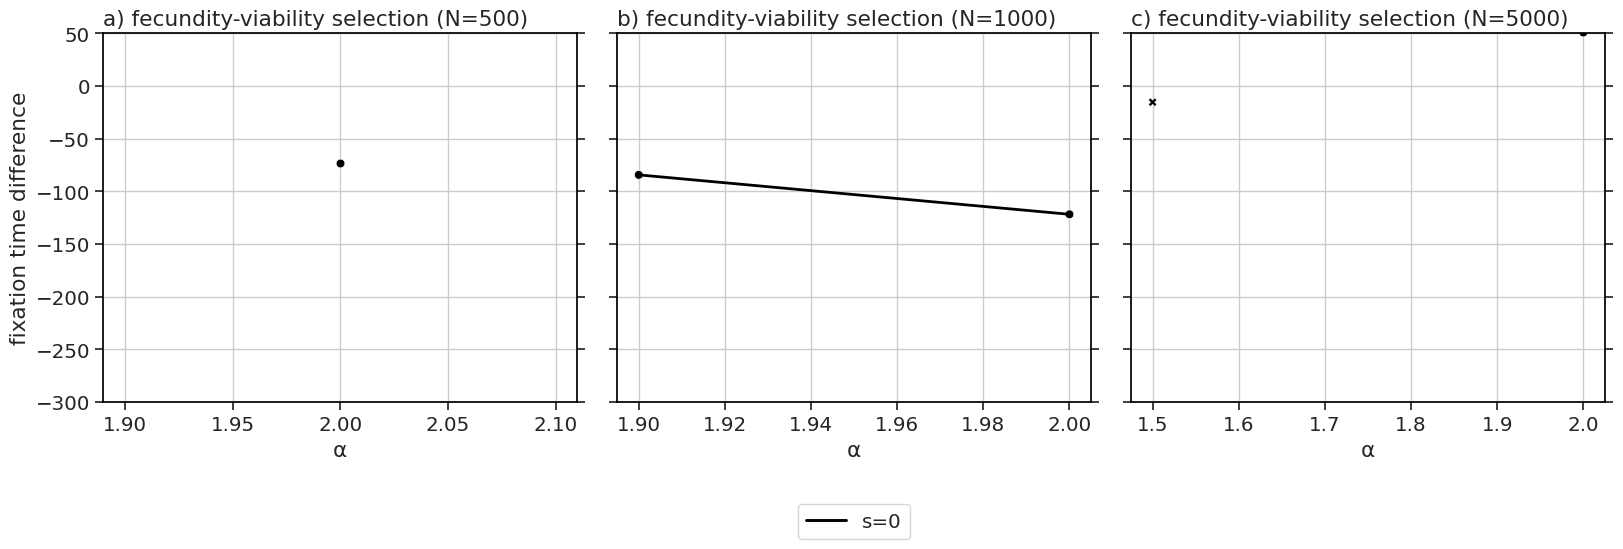

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(16.5, 6), sharey=True)

colors = ["#03045e", "#0077b6", "#00b4d8"]
colors = "black"
color = "black"
linewidth = 2


for i, population_size in enumerate(population_sizes):
    difference_frame_population__size = difference_frame[difference_frame["population_size"] == population_size]
    ax = axs[i]
    if i != 1:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color, legend=False)
    else:
        sns.lineplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",linewidth=2, style="selection_coefficient", ax=ax, color=color)

    sns.scatterplot(data=difference_frame_population__size, x="alpha", y="fecundity-viability",
                    s=40, style="selection_coefficient", ax=ax,  legend=False, color=color).set_title(pos_to_char(i) + ") fecundity-viability selection (N=" + str(population_size) + ")", loc="left")
    
    
    #for j, selection_coefficient in enumerate(selection_coefficients):
    #    std_frame = difference_frame_population__size[difference_frame_population__size["selection_coefficient"] == selection_coefficient]
    #    ax.fill_between(std_frame["alpha"], y1=std_frame["fecundity-viability"] - std_frame["standard_deviation"], y2=std_frame["fecundity-viability"] + std_frame["standard_deviation"], alpha=.15, color= color)

    
    ax.set(xlabel='α', ylabel='fixation time difference')
    ax.grid(True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    ##ax.patch.set_linewidth('2') 
    ax.set_ylim(-300, 50)


legend_pos=-0.25    
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol, labels=["s=0","s=0.01","s=0.1"])
for line in leg.get_lines():
    line.set_linewidth(2.1) 

plt.tight_layout()
plt.savefig("./figures/difference_time_fixation_population_constant_selection_shifted_sinus.pdf", dpi=500)


<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:97: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:97: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2921713/3613338601.py:64: SyntaxWarning: invalid escape sequence '\p'
  sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((578)/2) sin(0.05x + $\pi$) + (578)]")
/tmp/ipykernel_2921713/3613338601.py:80: SyntaxWarning: invalid escape sequence '\p'
  sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((1156)/2) sin(0.05x + $\pi$) + (1156)]")
/tmp/ipykernel_2921713/3613338601.py:97: SyntaxWarning: invalid escape sequence '\p'
  sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((5777)/2) sin(0.05x + $\pi$) + (5777)]")


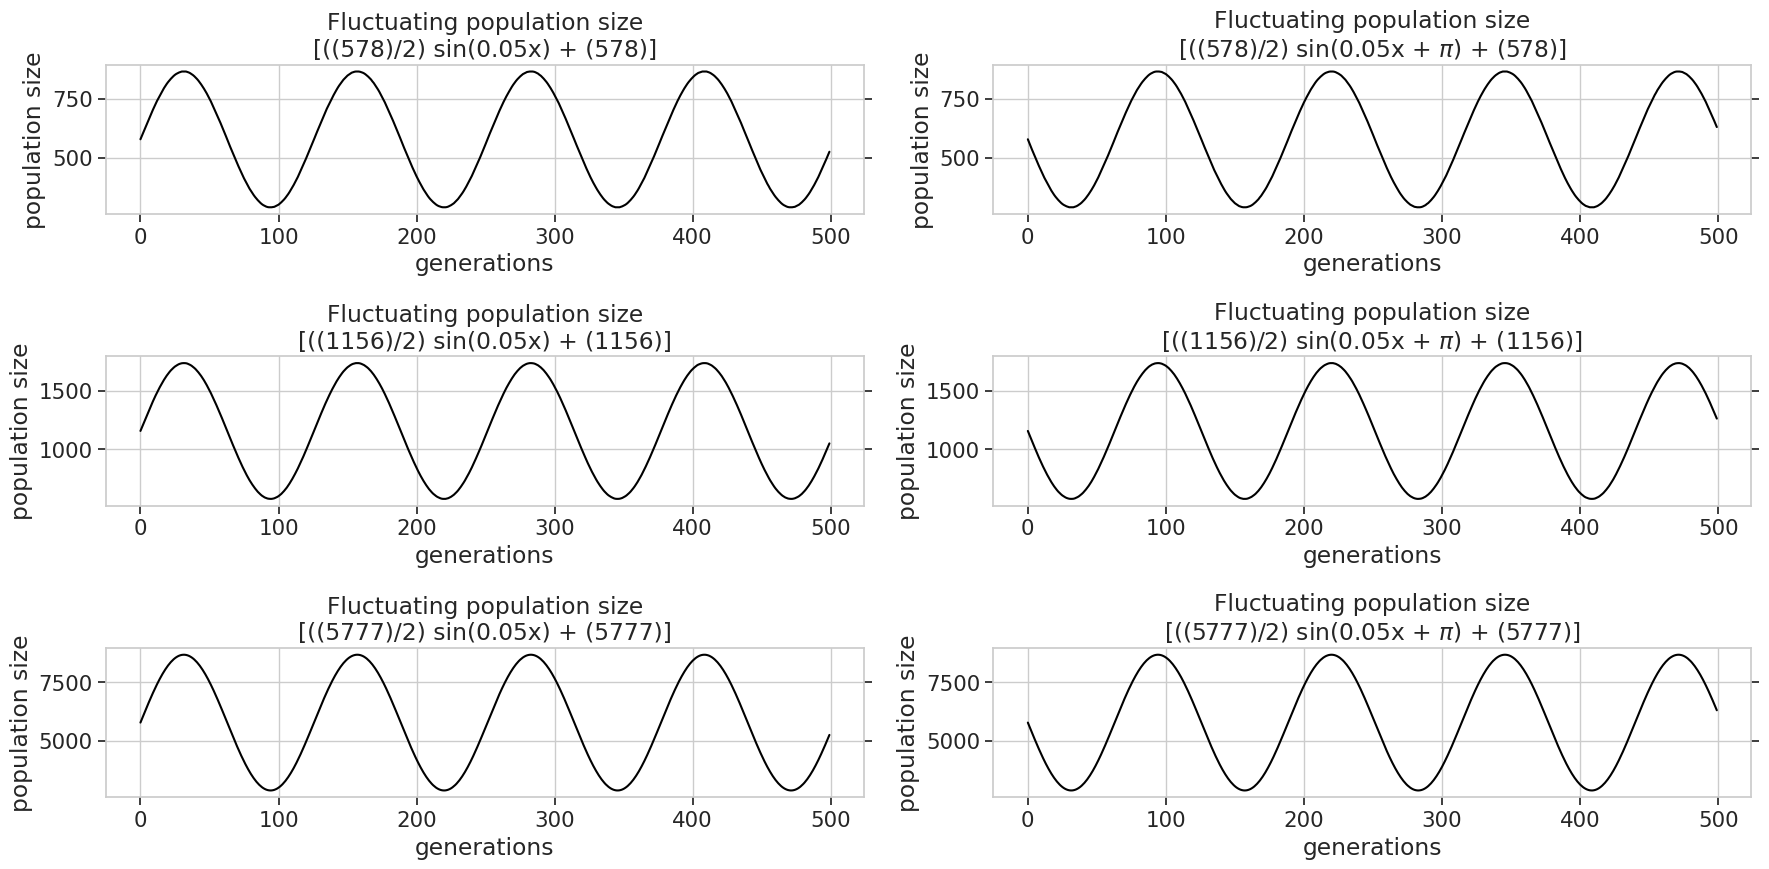

In [ ]:
sns.set(font_scale = 1.4, style="whitegrid")
fig, axs = plt.subplots(3,2, figsize=(18, 9), sharey=False)

N = 500
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 578
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x) + N_new
y = y.astype(int)
ax = axs[0][0]
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((578)/2) sin(0.05x) + (578)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
##ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')


ax = axs[1][0]
N = 1000
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 1156
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x) + N_new
y = y.astype(int)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((1156)/2) sin(0.05x) + (1156)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
##ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')



ax = axs[2][0]
N = 5000
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 5777
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x) + N_new
y = y.astype(int)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((5777)/2) sin(0.05x) + (5777)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
##ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')





N = 500
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 578
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x + np.pi) + N_new
y = y.astype(int)
ax = axs[0][1]
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((578)/2) sin(0.05x + $\pi$) + (578)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
##ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')


ax = axs[1][1]
N = 1000
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 1156
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x + np.pi) + N_new
y = y.astype(int)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((1156)/2) sin(0.05x + $\pi$) + (1156)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
##ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')



ax = axs[2][1]
N = 5000
period = 0.05
start ,stop, step = 0, 500, 1
N_new = 5777
x = np.arange(start, stop, step)  
y = N_new * 0.5 * np.sin(period * x + np.pi) + N_new
y = y.astype(int)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating population size\n[((5777)/2) sin(0.05x + $\pi$) + (5777)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
##ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='population size')

plt.tight_layout()
plt.savefig("./figures/fluctuating_population_size.pdf", dpi=500)

<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2921713/3853043987.py:23: SyntaxWarning: invalid escape sequence '\p'
  sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating selection coefficient\n[((1.01)*0.1) sin(0.1x + $\pi$) + (1.01-1)]")


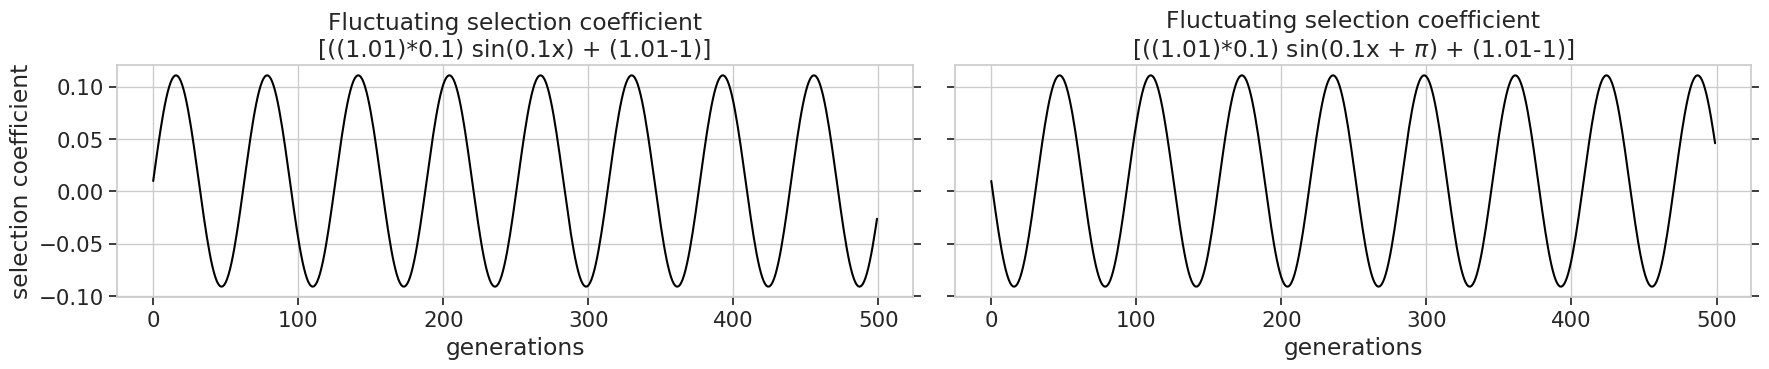

In [ ]:

sns.set(font_scale = 1.4, style="whitegrid")
fig, axs = plt.subplots(1,2, figsize=(18, 4), sharey=True)

ax = axs[0]
N = 1
period = 0.1
start ,stop, step = 0, 500, 1
x = np.arange(start, stop, step)  
y = (1.01) * 0.1 * np.sin(period * x) + (1.01-1)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating selection coefficient\n[((1.01)*0.1) sin(0.1x) + (1.01-1)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
#ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='selection coefficient')

ax = axs[1]
N = 1
period = 0.1
start ,stop, step = 0, 500, 1
x = np.arange(start, stop, step)  
y = (1.01) * 0.1 * np.sin(period * x + np.pi) + (1.01-1)
sns.lineplot(x=x, y=y, ax=ax, color="black").set_title("Fluctuating selection coefficient\n[((1.01)*0.1) sin(0.1x + $\pi$) + (1.01-1)]")
ax.grid(True)
ax.tick_params(bottom=True, top=False, left=True, right=True)
ax.patch.set_edgecolor('black')  
##ax.patch.set_linewidth('2') 
ax.set(xlabel='generations', ylabel='selection coefficient')


plt.tight_layout()
plt.savefig("./figures/fluctuating_selection_coefficient.pdf", dpi=500)



In [ ]:
from copy import deepcopy

In [ ]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "time" in file and "adapted" not in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]
viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

fecundity_constant_df["adapted_alpha"] = False
fecundity_constant_df_non_adapted_alpha = deepcopy(fecundity_constant_df)

In [ ]:
files = os.listdir("../src/simulations/")
files = ["../src/simulations/" + file for file in files]
# filter the times
df_time = [pd.read_csv(file) for file in files if "adapted" in file and "time" in file]
df_time = pd.concat(df_time).reset_index()

df = df_time[df_time["population_size_model"] == "constant"]

viability_constant_df = df[df["selection_type"] == "viability_constant"].reset_index()
fecundity_constant_df = df[df["selection_type"] == "fecundity_constant"].reset_index()
selection_coefficients = viability_constant_df.selection_coefficient.unique().tolist() 

fecundity_constant_df_adapted_alpha = deepcopy(fecundity_constant_df)


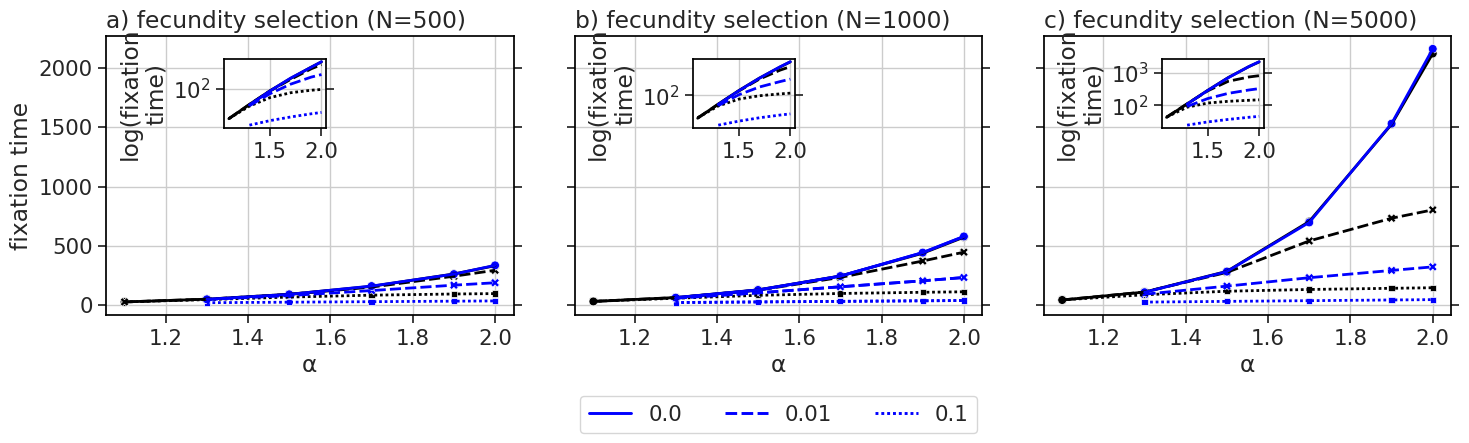

In [ ]:
sns.set_style("whitegrid", {'axes.edgecolor' : '.0001'})

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)



for i, population_size in enumerate([500, 1000, 5000]):
    
    
    
    
    fecundity_constant_df = deepcopy(fecundity_constant_df_non_adapted_alpha)
    
    colors = ["#03045e", "#0077b6", "#00b4d8"]
    colors = "black"
    color = "black"
    linewidth = 2

    ax = axs[i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    #if i == 1:
    #    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    ins = axs[i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    #ins.set_yscale("log")
    #ins.set(xlabel='', ylabel='log(fixation\ntime)')
    #ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    #ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    
    
    
    
    
    
    
    
    fecundity_constant_df = deepcopy(fecundity_constant_df_adapted_alpha)
    
    colors = ["#03045e", "#0077b6", "#00b4d8"]
    colors = "blue"
    color = "blue"
    linewidth = 2

    ax = axs[i]
    fecundity_constant_population_size = df = fecundity_constant_df[fecundity_constant_df["population_size"] == population_size]
    sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=False, color = color)
    
    for j, selection_coefficient in enumerate(selection_coefficients):
        std_frame = fecundity_constant_population_size[fecundity_constant_population_size["selection_coefficient"] == selection_coefficient]
        std_frame = std_frame.sort_values(by="parameter")
        ax.fill_between(std_frame["parameter"], y1=std_frame["fixation_time"] - std_frame["standard_deviation"], y2=std_frame["fixation_time"] + std_frame["standard_deviation"], alpha=.15, color = color)

    if i == 1:
        sns.lineplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, linewidth=2, legend=True, color = color)
    
    sns.scatterplot(data=fecundity_constant_population_size, x="parameter", y="fixation_time", style="selection_coefficient", ax=ax, s=40, legend=False, color = color).set_title(pos_to_char(i) + ") fecundity selection (N=" + str(population_size) + ")", loc="left")

    #ins = axs[i].inset_axes([0.29, 0.67, 0.25, 0.25])
    sns.lineplot(data=fecundity_constant_population_size,x="parameter", y="fixation_time", style="selection_coefficient", ax=ins, linewidth=2, legend=False, color = color)
    ins.set_yscale("log")
    ins.set(xlabel='', ylabel='log(fixation\ntime)')
    ins.patch.set_edgecolor('black')  
    #ins.patch.set_linewidth('2')
    ins.tick_params(bottom=True, top=False, left=True, right=True)
    ax.tick_params(bottom=True, top=False, left=True, right=True)
    ax.patch.set_edgecolor('black')  
    #ax.patch.set_linewidth('2') 
    ax.grid(True)
    ax.set(xlabel='α', ylabel='fixation time')
    

legend_pos=-0.25
ncol=3
ax=axs[1]
box = ax.get_position()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h, loc='upper center',bbox_to_anchor=(0.5, legend_pos), fancybox=True, shadow=False, ncol=ncol) #labels=["s=0","s=0.01","s=0.1"]
for line in leg.get_lines():
    line.set_linewidth(2.1) 
            

plt.tight_layout()
plt.savefig("./figures/time_fixation_population_constant_selection_constant_diff-model.pdf", dpi=500)